In [974]:
# CELL 1 - RUN THIS FIRST
import tensorflow as tf
import gc
from tensorflow import keras

# Clear and configure GPU
keras.backend.clear_session()
gc.collect()

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("✓ GPU configured")

✓ GPU configured


In [975]:
# ============================================================================
# FIXED GRAD-CAM LOCALIZATION EVALUATION
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf
from tensorflow import keras
import cv2
import os
from tensorflow.keras import layers

In [976]:
# ============================================================================
# CONFIGURATION
# ============================================================================

IMAGE_SIZE = 224
ORIGINAL_SIZE = 1024  # Original image dimensions
MODEL_PATH = './output/pneumo_resnet50_cbam.keras'
CSV_PATH = './dataset_pneumothorax/pneumothorax_xy.csv'
IMAGE_DIR = './dataset_pneumothorax/images'

In [977]:
# ============================================================================
# CBAM ATTENTION MODULE IMPLEMENTATION
# ============================================================================

class ChannelAttention(layers.Layer):
    """Channel Attention Module"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.ratio = ratio
    
    def build(self, input_shape):
        channels = input_shape[-1]
        self.shared_dense_one = layers.Dense(
            channels // self.ratio,
            activation='relu',
            kernel_initializer='he_normal',
            use_bias=True
        )
        self.shared_dense_two = layers.Dense(
            channels,
            kernel_initializer='he_normal',
            use_bias=True
        )
        super(ChannelAttention, self).build(input_shape)
    
    def call(self, inputs):
        # Average pooling
        avg_pool = layers.GlobalAveragePooling2D()(inputs)
        avg_pool = layers.Reshape((1, 1, inputs.shape[-1]))(avg_pool)
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)
        
        # Max pooling
        max_pool = layers.GlobalMaxPooling2D()(inputs)
        max_pool = layers.Reshape((1, 1, inputs.shape[-1]))(max_pool)
        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)
        
        # Combine and apply sigmoid
        channel_attention = layers.Add()([avg_pool, max_pool])
        channel_attention = layers.Activation('sigmoid')(channel_attention)
        
        return layers.Multiply()([inputs, channel_attention])
    
    def get_config(self):
        config = super(ChannelAttention, self).get_config()
        config.update({'ratio': self.ratio})
        return config


class SpatialAttention(layers.Layer):
    """Spatial Attention Module"""
    def __init__(self, kernel_size=7, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
    
    def build(self, input_shape):
        self.conv = layers.Conv2D(
            filters=1,
            kernel_size=self.kernel_size,
            strides=1,
            padding='same',
            activation='sigmoid',
            kernel_initializer='he_normal',
            use_bias=False
        )
        super(SpatialAttention, self).build(input_shape)
    
    def call(self, inputs):
        # Average pooling along channel axis
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        
        # Max pooling along channel axis
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        
        # Concatenate
        concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
        
        # Apply convolution
        spatial_attention = self.conv(concat)
        
        return layers.Multiply()([inputs, spatial_attention])
    
    def get_config(self):
        config = super(SpatialAttention, self).get_config()
        config.update({'kernel_size': self.kernel_size})
        return config


class CBAM(layers.Layer):
    """Convolutional Block Attention Module (CBAM)"""
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super(CBAM, self).__init__(**kwargs)
        self.channel_attention = ChannelAttention(ratio=ratio)
        self.spatial_attention = SpatialAttention(kernel_size=kernel_size)
    
    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x
    
    def get_config(self):
        config = super(CBAM, self).get_config()
        return config

In [978]:
# ============================================================================
# LOAD DATA AND MODEL
# ============================================================================

df = pd.read_csv(CSV_PATH)
model = keras.models.load_model(MODEL_PATH, custom_objects={
        'CBAM': CBAM,
        'ChannelAttention': ChannelAttention,
        'SpatialAttention': SpatialAttention
    })

print(f"Loaded {len(df)} pneumothorax images with bounding boxes")
print(f"Scale factor: {IMAGE_SIZE}/{ORIGINAL_SIZE} = {IMAGE_SIZE/ORIGINAL_SIZE:.4f}")

Loaded 98 pneumothorax images with bounding boxes
Scale factor: 224/1024 = 0.2188


In [979]:
def get_cbam_spatial_attention(img_array, model):
    """Extract full CBAM attention (channel + spatial)."""
    base_model = model.get_layer('resnet50v2')
    cbam_layer = model.get_layer('cbam_attention')
    
    # Get features and apply full CBAM
    features = base_model(img_array)
    cbam_output = cbam_layer(features)
    
    # Average across channels to get spatial importance
    spatial_map = tf.reduce_mean(cbam_output, axis=-1).numpy()[0]
    
    # Normalize
    spatial_map = (spatial_map - spatial_map.min()) / (spatial_map.max() - spatial_map.min() + 1e-8)
    
    return cv2.resize(spatial_map, (IMAGE_SIZE, IMAGE_SIZE))

In [980]:
# ============================================================================
# LOAD AND PREPROCESS IMAGE
# ============================================================================
def load_and_preprocess_image(image_path):
    """Load image and calculate scale factor."""
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    
    img_display = img.numpy().astype(np.uint8)
    img = tf.keras.applications.resnet_v2.preprocess_input(img)
    img_array = tf.expand_dims(img, 0)
    
    scale_factor = IMAGE_SIZE / ORIGINAL_SIZE
    
    return img_array, img_display, scale_factor

In [981]:
# ============================================================================
# METRICS FUNCTIONS
# ============================================================================
def compute_iou_from_heatmap(heatmap, bbox, threshold=0.5):
    """Compute IoU between thresholded heatmap and ground truth bbox."""
    binary_map = (heatmap >= threshold).astype(np.uint8)
    
    gt_mask = np.zeros_like(binary_map)
    x, y, w, h = map(int, bbox)
    
    # Ensure bbox is within image bounds
    x = max(0, min(x, IMAGE_SIZE - 1))
    y = max(0, min(y, IMAGE_SIZE - 1))
    w = max(1, min(w, IMAGE_SIZE - x))
    h = max(1, min(h, IMAGE_SIZE - y))
    
    gt_mask[y:y+h, x:x+w] = 1
    
    intersection = np.logical_and(binary_map, gt_mask).sum()
    union = np.logical_or(binary_map, gt_mask).sum()
    
    iou = intersection / union if union > 0 else 0.0
    
    return iou

def pointing_game(heatmap, bbox):
    """Check if max attention is inside bounding box."""
    max_loc = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    max_y, max_x = max_loc
    
    x, y, w, h = map(int, bbox)
    hit = (x <= max_x < x + w) and (y <= max_y < y + h)
    
    return 1 if hit else 0

In [ ]:
# ============================================================================
# EVALUATION ON SPECIFIC IMAGE
# ============================================================================


SPECIFIC_IMAGE = '00026886_002.png'  

# sample = df[df['Image Index'] == SPECIFIC_IMAGE]
sample = df.sample(1)
if sample.empty:
    print(f"⚠ Specific image '{SPECIFIC_IMAGE}' not found in dataset. Falling back to random sample.")
    sample = df.sample(1)
else:
    sample = sample.iloc[0]

image_name = sample['Image Index']
x_orig = float(sample['x'])
y_orig = float(sample['y'])
w_orig = float(sample['w'])
h_orig = float(sample['h'])

print(f"\n{'='*80}")
print(f"EVALUATION ON SPECIFIC IMAGE: {image_name}")
print(f"{'='*80}")
print(f"Original BBox (1024x1024): x={x_orig:.1f}, y={y_orig:.1f}, w={w_orig:.1f}, h={h_orig:.1f}")

# Load image
image_path = os.path.join(IMAGE_DIR, image_name)
try:
    img_array, img_display, scale_factor = load_and_preprocess_image(image_path)
except FileNotFoundError as e:
    print(f"Error: {e}")
    exit(1)

# Scale bounding box
x = x_orig * scale_factor
y = y_orig * scale_factor
w = w_orig * scale_factor
h = h_orig * scale_factor
bbox = [x, y, w, h]

print(f"Scaled BBox (224x224): x={x:.1f}, y={y:.1f}, w={w:.1f}, h={h:.1f}")
print(f"Scale factor: {scale_factor:.4f}")

# Get prediction
prediction = model.predict(img_array, verbose=0)[0][0]
print(f"\nModel Prediction: {prediction:.4f} (Pneumothorax probability)")

# Generate attention heatmap from CBAM spatial attention
heatmap = get_cbam_spatial_attention(img_array, model)

# Compute metrics
iou = compute_iou_from_heatmap(heatmap, bbox, threshold=0.5)
pointing_acc = pointing_game(heatmap, bbox)

print(f"\n{'='*80}")
print(f"LOCALIZATION METRICS (Using CBAM Spatial Attention)")
print(f"{'='*80}")
print(f"IoU (Intersection over Union): {iou:.4f}")
print(f"Pointing Game Accuracy: {pointing_acc} ({'HIT ✓' if pointing_acc else 'MISS ✗'})")


EVALUATION ON SPECIFIC IMAGE: 00029259_027.png
Original BBox (1024x1024): x=787.8, y=386.8, w=112.7, h=291.5
Scaled BBox (224x224): x=172.3, y=84.6, w=24.7, h=63.8
Scale factor: 0.2188

Model Prediction: 0.9855 (Pneumothorax probability)

LOCALIZATION METRICS (Using CBAM Spatial Attention)
IoU (Intersection over Union): 0.1132
Pointing Game Accuracy: 1 (HIT ✓)


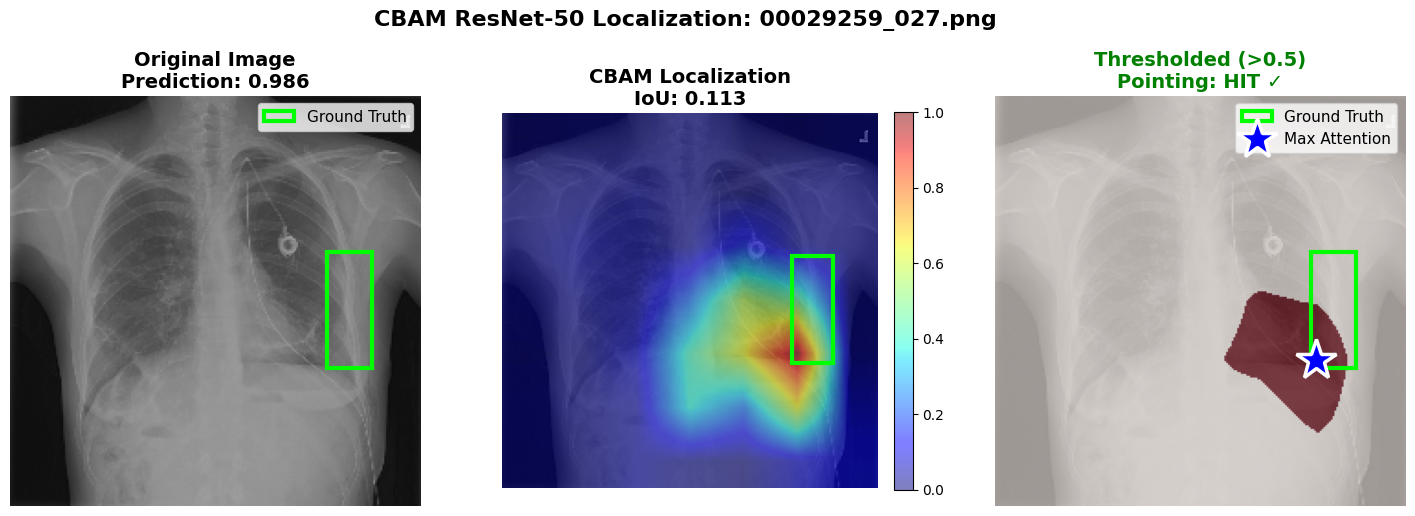

In [983]:
# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original image with bbox
axes[0].imshow(img_display)
rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='lime', facecolor='none', label='Ground Truth')
axes[0].add_patch(rect)
axes[0].set_title(f'Original Image\nPrediction: {prediction:.3f}', fontsize=14, fontweight='bold')
axes[0].axis('off')
axes[0].legend(fontsize=11, loc='upper right')

# 2. CBAM Spatial Attention overlay
axes[1].imshow(img_display)
heatmap_overlay = axes[1].imshow(heatmap, cmap='jet', alpha=0.5, vmin=0, vmax=1)
rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='lime', facecolor='none')
axes[1].add_patch(rect)
axes[1].set_title(f'CBAM Localization\nIoU: {iou:.3f}', fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.colorbar(heatmap_overlay, ax=axes[1], fraction=0.046, pad=0.04)

# 3. Thresholded attention with max point
binary_map = (heatmap >= 0.5).astype(np.uint8)
axes[2].imshow(img_display)
axes[2].imshow(binary_map, cmap='Reds', alpha=0.6)
rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor='lime', facecolor='none', label='Ground Truth')
axes[2].add_patch(rect)

# Mark max attention point
max_loc = np.unravel_index(np.argmax(heatmap), heatmap.shape)
max_y_coord, max_x_coord = max_loc
axes[2].plot(max_x_coord, max_y_coord, 'b*', markersize=30, markeredgewidth=2.5, 
             markeredgecolor='white', label='Max Attention')

color = 'green' if pointing_acc else 'red'
axes[2].set_title(f'Thresholded (>0.5)\nPointing: {"HIT ✓" if pointing_acc else "MISS ✗"}', 
                  fontsize=14, fontweight='bold', color=color)
axes[2].axis('off')
axes[2].legend(fontsize=11, loc='upper right')

plt.suptitle(f'CBAM ResNet-50 Localization: {image_name}', fontsize=16, fontweight='bold')
plt.subplots_adjust()
plt.show()